## Estimate $C_L^{KK}$ from simple simulations, test general $<K(T_A, T_B) K(T_C, T_D)>$ estimator

This note book goes through most of the basics of estimating $C_L^{KK}$. We do this one simple simulations
with Gaussian CMB and noise, and kSZ signal from the Alvarez 2015 simulations. 

We use the functions `setup_recon_simple` and `setup_ABCD_recon` to setup various stuff we need to estimate 
K (e.g. the filter functions, the quadratic estimator functions to apply to the filtered maps, theory N0s etc.).

We then generate simulations and apply these tools, ensuring that the recovery of $C_L^{KK}$ is consistent between 
various configurations:
- kSZ-only (i.e. no noise or CMB in the maps)
- The same map, labelled X, in each leg of the trispectrum 
- A map with different but correlated noise, labelled Y, in one leg of the trispectrum (labelled "XYXX" below). 

In [1]:
import healpy as hp
import matplotlib
import matplotlib.pyplot as plt
import os
os.environ["DISABLE_MPI"]="true"
import numpy as np
from falafel import utils, qe
import pytempura
from pixell import lensing, curvedsky, enmap
from pixell import utils as putils
from os.path import join as opj
import argparse
import yaml
from collections import OrderedDict
from orphics import maps
import sys
from scipy.signal import savgol_filter
from ksz4 import setup_recon_simple, setup_ABCD_recon, safe_mkdir, get_disable_mpi, get_cmb_alm_unlensed, ClBinner, get_cl_smooth

Set some options here for the K "reconstruction" and simulations. We're going to 
be estimating $C_L^{KK}$ from CMB temperature maps labelled X and Y, which have the 
same signal, but different (but correlated) noise. This is similar to the case if e.g. one of the
legs in the K estimator has some foreground spectrum deprojection applied. 

- lmin, lmax are the CMB temperature minimum and maximum l used 
- noise_sigma_X, noise_sigma_Y and r are the noise standard deviations 
for maps X and Y, and their noise cross-correlation coefficients


In [2]:
shape,wcs = enmap.fullsky_geometry(1.*putils.arcmin)
px=qe.pixelization(shape=shape,wcs=wcs)
mlmax=4000
lmin=3000
lmax=4000

#binning function for C_L^KK
binner=ClBinner(lmin=10, lmax=200, nbin=15)

Noise levels and beam for simulations

In [3]:
noise_sigma_X = 2.
noise_sigma_Y = 5.
#cross-correlation coefficient 
r = 0.5

#assume Gaussian beam with fwhm=1. arcmin
beam_fwhm=1.
ells = np.arange(mlmax+1)
beam = maps.gauss_beam(ells, beam_fwhm)
Nl_tt_X = (noise_sigma_X*np.pi/180./60.)**2./beam**2
Nl_tt_Y = (noise_sigma_Y*np.pi/180./60.)**2./beam**2
#We need N_l for generating uncorrelated component of Y,
#call this map Z
#We have noise_Y = a*noise_X + noise_Z
#then N_l^Y = a^2 N_l^X + N_l^Z
#and <XY> = a * N_l^X = r_l * sqrt(N_l^X N_l^Y) (from defintion of r_l)
#then we have a = r_l*sqrt(N_l^X N_l^Y) / N_l^X
#and N_l^Z = N_l^Y - a^2 N_l^X 
a = r * np.sqrt(Nl_tt_X*Nl_tt_Y)/Nl_tt_X
Nl_tt_Z = Nl_tt_Y - a**2 * Nl_tt_X
nells_X = {"TT":Nl_tt_X, "EE":2*Nl_tt_X, "BB":2*Nl_tt_X}
nells_Y = {"TT":Nl_tt_Y, "EE":2*Nl_tt_Y, "BB":2*Nl_tt_Y}

#Get total noise using convenience function from falafel.utils
_,tcls_X = utils.get_theory_dicts(grad=True, nells=nells_X, lmax=mlmax)
_,tcls_Y = utils.get_theory_dicts(grad=True, nells=nells_Y, lmax=mlmax)
_,tcls_nonoise = utils.get_theory_dicts(grad=True, lmax=mlmax)

Now read in kSZ signal alms from Alvarez 2015, we'll use these to
- add kSZ signal to the sims
- we'll also use the power spectrum in the filters 

In [ ]:
#download alms using wget (I already converted the map to alms)
!wget -N https://portal.nersc.gov/project/act/maccrann/alms_4e3_2048_50_50_ksz_lmax4000.fits

In [4]:
#Read in alms
ksz_alm = utils.change_alm_lmax(hp.fitsfunc.read_alm("alms_4e3_2048_50_50_ksz_lmax4000.fits"),
                                mlmax)
cl_rksz = get_cl_smooth(ksz_alm)[:mlmax+1]
#tcls_X['TT'] += cl_rksz
#tcls_Y['TT'] += cl_rksz
##tcls_nonoise['TT'] += cl_rksz
#
#
#cltot_X = tcls_X['TT'][:mlmax+1]-tcls_nonoise['TT']
#cltot_Y = tcls_Y['TT'][:mlmax+1]-tcls_nonoise['TT']
#cltot_XY = (tcls_nonoise['TT'] + r*np.sqrt(Nl_tt_X*Nl_tt_Y))[:mlmax+1]-tcls_nonoise['TT']
cltot_X = tcls_X['TT'][:mlmax+1] + cl_rksz
cltot_Y = tcls_Y['TT'][:mlmax+1] + cl_rksz
cltot_XY = (tcls_nonoise['TT'] + cl_rksz + r*np.sqrt(Nl_tt_X*Nl_tt_Y))[:mlmax+1]

no_cmb=False
if no_cmb:
    cltot_X -= tcls_nonoise['TT']
    cltot_Y -= tcls_nonoise['TT']
    cltot_XY -= tcls_nonoise["TT"]


In [5]:
divide_by_2uL=True

simple_setup = setup_recon_simple(
    px, lmin, lmax,
    mlmax,  cl_rksz, cltot_X,
    do_lh=False, do_psh=False,
    divide_by_2uL=divide_by_2uL
)
abcd_setup_XX = setup_ABCD_recon(
    px, lmin, lmax,
    mlmax,  cl_rksz, cltot_X, cltot_X,
    cltot_X, cltot_X,
    cltot_X, cltot_X,
    cltot_X, cltot_X,
    do_lh=False, do_psh=False,
    divide_by_2uL=divide_by_2uL)

#This is an XYXX estimator (i.e. just one of the four legs uses a different map ("Y") to the other three)
abcd_setup_XYXX = setup_ABCD_recon(
    px, lmin, lmax,
    mlmax,  cl_rksz, 
    cltot_X, cltot_Y,
    cltot_X, cltot_X,
    cltot_X, cltot_XY,
    cltot_X, cltot_XY,
    do_lh=False, do_psh=False,
    divide_by_2uL=divide_by_2uL)

############
do_psh: False
#############
getting qe N0s
getting qe fg_trispectrum functions
getting AB and CD qfuncs for qe
############
do_psh: False
#############
getting qe N0s
getting qe fg_trispectrum functions
getting AB and CD qfuncs for qe


### Plot some of the quantities the setup functions have calculated 

First the normalizations, these are the quantities the raw quadratic estimator is multiplied by (this is done automatically within the "qfunc" functions). But just check they are consistent

Then the N0s. These are the Gaussian noise corrections for $C_L^{KK}$. It is slightly different for the XYXX case since the Y map has different noise.

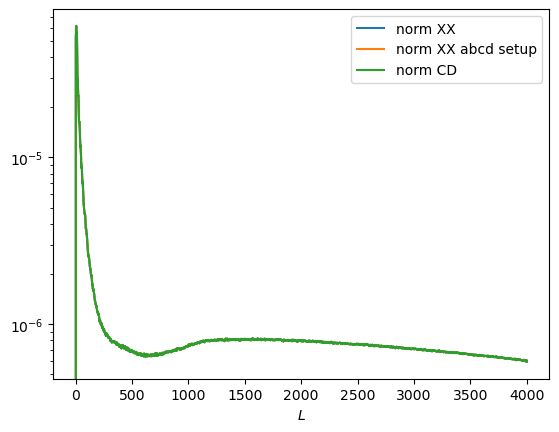

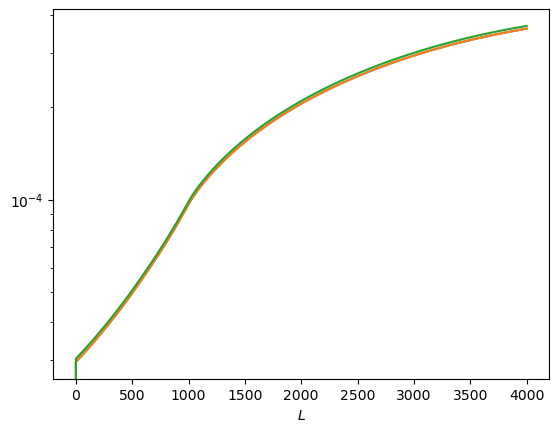

In [6]:
%matplotlib inline

#fig,ax=plt.subplots()

#ax.plot(normal_setup["profile"])
#ax.plot(abcd_setup_XX["profile"])
#ax.set_yscale('log')

notinf=np.where(np.isfinite(abcd_setup_XX["norm_K_AB"]))
assert np.allclose(abcd_setup_XX["norm_K_AB"][notinf], abcd_setup_XYXX["norm_K_CD"][notinf])

fig,ax=plt.subplots()
ax.plot(simple_setup["norm_K"], label="norm XX")
ax.plot(abcd_setup_XX["norm_K_AB"], label="norm XX abcd setup")
ax.plot(abcd_setup_XYXX["norm_K_CD"], label="norm CD")
ax.set_yscale("log")
ax.set_xlabel("$L$")
ax.legend()
        
        

fig,ax=plt.subplots()
ax.plot(simple_setup["N0_K"], label="$N^0$ XXXX")
ax.plot(abcd_setup_XX["N0_ABCD_K"], label="$N^0$ XXXX, abcd setup")
ax.plot(abcd_setup_XYXX["N0_ABCD_K"], label="N^0$ XYXX")
ax.set_xlabel("$L$")
ax.set_yscale("log")

In [7]:
from cmbsky.utils import get_cmb_alm_unlensed
nsim=1

cl_dict = {"KK_XX" : [],
           "KK_abcd_XX" : [],
           "KK_XXxi" : [],
           "KK_abcd_XXxi" : [],
           "KK_XX_gaussian" : [],
           #"KK_abcd_XX_gaussian" : [],
           "KK_XYXX" : [],
           "KK_XYXX_gaussian" : [],
           "tcl_XX" : [],
           "tcl_XY" : [],
          }
do_qe=True
rank,size=0,1

First run the estimator on (filtered) kSZ-only alms. We use the `"qfunc_K"` and `"qfunc_K_AB"` entries of the 
setup dictionaries to estimate (normalised) `K`. Then use `alm2cl` to get $C_L^{KK}$ (note this won't be $N^0$ subtracted). 

Note that these quadratic estimator functions operate on *filtered maps*. The setup dictionaries also contain the filter functions. 

In [8]:
#do ksz only
Xf_ksz = simple_setup["filter"](ksz_alm.copy())
assert np.allclose(abcd_setup_XX["filter_A"](ksz_alm.copy()), Xf_ksz)
if rank==0:
    print("rank 0 doing ksz only")
    
    K_XX_kszonly = simple_setup["qfunc_K"](Xf_ksz, Xf_ksz)
    K_abcd_XX_kszonly = abcd_setup_XX["qfunc_K_AB"](Xf_ksz, Xf_ksz)
    cl_KK_XX_kszonly = binner(curvedsky.alm2cl(
        K_XX_kszonly
    ))
    cl_KK_abcd_XX_kszonly = binner(curvedsky.alm2cl(
        K_abcd_XX_kszonly
    ))
    

rank 0 doing ksz only


In [9]:
if rank==0:
    #also get ksz-only N0
    N0_XX_kszonly = simple_setup["get_fg_trispectrum_K_N0"](
        cl_rksz
    )
    N0_abcd_XX_kszonly = abcd_setup_XX["get_fg_trispectrum_N0_ABCD"](
        cl_rksz, cl_rksz, cl_rksz, cl_rksz
    )

/global/cfs/projectdirs/act/data/maccrann/lenspipe_new/lib/python3.10/site-packages/ksz4/reconstruction.py:725: RuntimeWarning: invalid value encountered in divide
  N0_tri = N0_K**2 / norm_fg


(4001,)


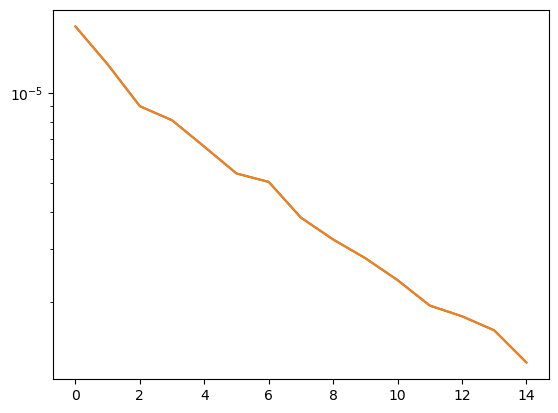

In [10]:
%matplotlib inline

fig,ax=plt.subplots()

ax.plot(cl_KK_XX_kszonly - binner(N0_XX_kszonly))
ax.plot(cl_KK_abcd_XX_kszonly - binner(N0_abcd_XX_kszonly))

ax.set_yscale('log')

## Generate simulations to test 
- recovery of signal 
- Analytic N0 calcualation (since this should agree with result of estimator on Gaussian sims)
- Test "XXXX" case and "XYXX" case.

In [12]:
#Loop over nsim simulations
for isim in range(nsim):
    if size>1:
        if isim%size != rank-1:
            continue
    print("rank %d doing sim %d"%(rank,isim))
    print("reading cmb  alm")
    #get unlensed cmb (since lensed cmb will be biased - 
    #we'll deal with this later)
    cmb_alm_unlensed = curvedsky.rand_alm(tcls_nonoise["TT"], seed=isim*(10*nsim))
    cmb_alm_unlensed = utils.change_alm_lmax(cmb_alm_unlensed, mlmax)

    # Generate noise 
    # 
    print("generating noise")
    noise_alm_X = curvedsky.rand_alm(Nl_tt_X, seed=isim*(10*nsim)+1)
    noise_alm_Z = curvedsky.rand_alm(Nl_tt_Z, seed=isim*(10*nsim)+2)
    noise_alm_Y = curvedsky.almxfl(noise_alm_X,a) + noise_alm_Z

    X_ksz = ksz_alm.copy()
    X = cmb_alm_unlensed+noise_alm_X+ksz_alm
    Y = cmb_alm_unlensed+noise_alm_Y+ksz_alm
    cl_dict["tcl_XX"].append(
        curvedsky.alm2cl(X,X))
    cl_dict["tcl_XY"].append(
        curvedsky.alm2cl(X,Y))
    Xf, Yf = abcd_setup_XX["filter_A"](X), abcd_setup_XYXX["filter_B"](Y)
    assert np.allclose(Xf, simple_setup["filter"](X))

    ksz_alm_gaussian = curvedsky.rand_alm(cl_rksz, seed=isim*(10*nsim)+3)
    X_gaussian = cmb_alm_unlensed + noise_alm_X + ksz_alm_gaussian
    Y_gaussian = cmb_alm_unlensed + noise_alm_Y + ksz_alm_gaussian
    X_gaussianf, Y_gaussianf = (
        abcd_setup_XX["filter_A"](X_gaussian), 
        abcd_setup_XYXX["filter_B"](Y_gaussian)
    )
    
    #X_noksz = cmb_alm+noise_alm_X
    #Y_noksz = cmb_alm+noise_alm_Y
    #Xf_noksz, Yf_noksz = asym_setup["filter_X"](X_noksz), asym_setup["filter_Y"](Y_noksz)

    #X_fg_gaussian = curvedsky.rand_alm(cl_fg_X, seed=isim*(10*nsim)+3)
    #Y_fg_gaussian = 0.1*X_fg_gaussian

    print("running K estimators")
    if do_qe:
        print("qe case:")
        #K_XY = asym_setup["qfunc_K_XY"](Xf, Yf)
        #get signal
        K_abcd_XX = abcd_setup_XX["qfunc_K_AB"](Xf,Xf)
        K_XX = simple_setup["qfunc_K"](Xf,Xf)
        print("K_abcd_XX==K_XX?", np.allclose(K_abcd_XX,K_XX))
        
        #for the XYXX version, we need to
        #get K_XY, but the K_XX in the other leg
        #should be the same as what we already computed.
        #but check this
        K_abcd_XY = abcd_setup_XYXX["qfunc_K_AB"](
            Xf, Yf)
        if isim==0:
            isfin = np.where(np.isfinite(K_abcd_XX))
            assert np.allclose(
                abcd_setup_XYXX["qfunc_K_CD"](Xf, Xf)[isfin],
                K_abcd_XX[isfin])
        
        #also run on Gaussian sims to test N0
        K_abcd_XX_gaussian = abcd_setup_XX["qfunc_K_AB"](
            X_gaussianf, X_gaussianf)
        K_XX_gaussian = simple_setup["qfunc_K"](
            X_gaussianf, X_gaussianf)
    
        K_abcd_XY_gaussian = abcd_setup_XYXX["qfunc_K_AB"](
            X_gaussianf, Y_gaussianf)
        #K_abcd_XX_gaussian = abcd_setup_XYXX["qfunc_K_CD"](
        #    X_gaussianf, X_gaussianf)
        
        #K_XY_noksz = asym_setup["qfunc_K_XY"](Xf_noksz, Yf_noksz)

        #auto
        #cl_dict["KK_XY"].append(binner(
        #    curvedsky.alm2cl(K_XY)
        #))
        cl_dict["KK_XX"].append(binner(
            curvedsky.alm2cl(K_XX)
        ))              
        cl_dict["KK_abcd_XX"].append(binner(
            curvedsky.alm2cl(K_abcd_XX)
        ))
        cl_dict["KK_XX_gaussian"].append(binner(
            curvedsky.alm2cl(K_XX_gaussian)
        ))              
        #cl_dict["KK_abcd_XX_gaussian"].append(binner(
        #    curvedsky.alm2cl(K_abcd_XX_gaussian)
        #))
        cl_dict["KK_XYXX"].append(binner(
            curvedsky.alm2cl(K_abcd_XY, K_abcd_XX)
        ))
        cl_dict["KK_XYXX_gaussian"].append(binner(
            curvedsky.alm2cl(K_abcd_XY_gaussian, K_abcd_XX_gaussian)
        ))
        #cl_dict["KK_XY_noksz"].append(binner(
        #    curvedsky.alm2cl(K_XY_noksz)
        #))
        #cl_dict["KK_XXxi"].append(binner(
        #    curvedsky.alm2cl(K_XX, K_XX_kszonly)
        #))
        #cl_dict["KK_abcd_XXxi"].append(binner(
        #    curvedsky.alm2cl(K_abcd_XX, K_XX_kszonly)
        #))
        
for key in cl_dict:
    cl_dict[key] = np.array(cl_dict[key])

rank 0 doing sim 0
reading cmb  alm
generating noise
running K estimators
qe case:
K_abcd_XX==K_XX? True


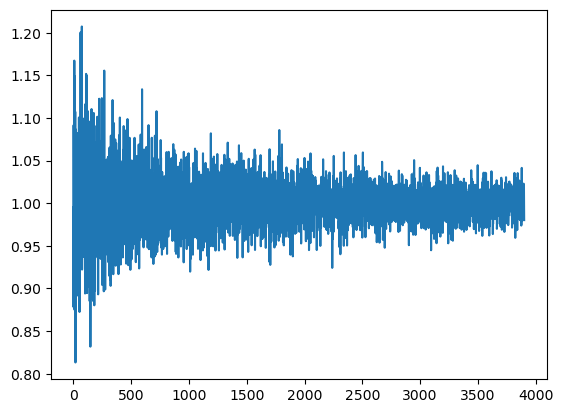

In [13]:
%matplotlib inline

fig,ax=plt.subplots()

ax.plot((cl_dict["tcl_XX"].mean(axis=0)/cltot_X)[100:])


Check signal (compare to kSZ-only case). All three of
- the XX x XX case using ``normal setup''
- the XX x XX case using ``abcd_setup_XX'
- the XY x XX case using ``abcd_setup_XYXX'

Text(0, 0.5, '$C_L^{KK}$')

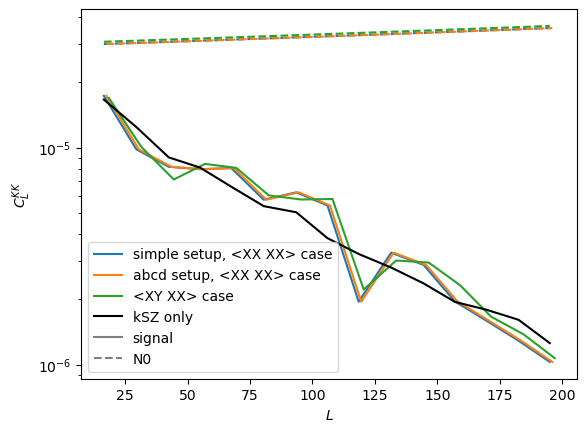

In [14]:
%matplotlib inline

fig,ax=plt.subplots()

cl_KK_XX = cl_dict["KK_XX"].mean(axis=0)  -  binner(simple_setup["N0_K"])
cl_KK_abcd_XX = cl_dict["KK_abcd_XX"].mean(axis=0) - binner(abcd_setup_XX["N0_ABCD_K"])
cl_KK_XYXX = cl_dict["KK_XYXX"].mean(axis=0) - binner(abcd_setup_XYXX["N0_ABCD_K"])

cl_KK_kszonly = cl_KK_XX_kszonly - binner(N0_XX_kszonly)

ax.plot(binner.bin_mids, cl_KK_XX, label="simple setup, <XX XX> case", color="C0")
ax.plot(binner.bin_mids, binner(simple_setup["N0_K"]), '--', color="C0")
ax.plot(1+binner.bin_mids, cl_KK_abcd_XX, label="abcd setup, <XX XX> case", color="C1")
ax.plot(1+binner.bin_mids, binner(abcd_setup_XX["N0_ABCD_K"]), '--', color="C1")
ax.plot(2+binner.bin_mids, cl_KK_XYXX, label="<XY XX> case", color="C2")
ax.plot(binner.bin_mids, binner(abcd_setup_XYXX["N0_ABCD_K"]), '--', color="C2")
ax.plot(binner.bin_mids, cl_KK_kszonly, label="kSZ only", color="k")
ax.plot([],[],"k-", alpha=0.5, label="signal")
ax.plot([],[],"k--",alpha=0.5, label="N0")

ax.legend()

ax.set_yscale('log')
ax.set_xlabel(r"$L$")
ax.set_ylabel(r"$C_L^{KK}$")

Check N^0 (compare theory calculation to Gaussian sims)

Text(0, 0.5, 'sim $N^0$ / theory $N^0$')

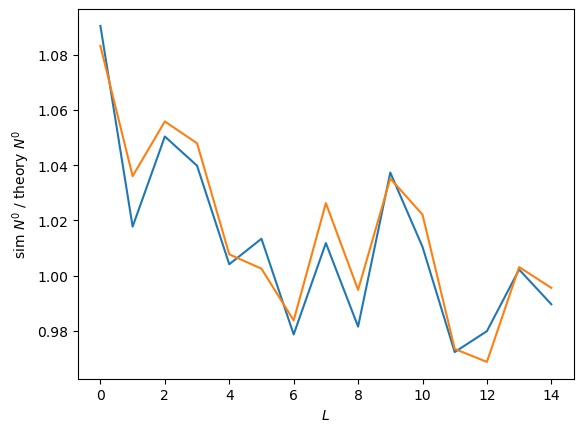

In [15]:
%matplotlib inline

fig,ax=plt.subplots()

cl_KK_XX_gaussian = cl_dict["KK_XX_gaussian"].mean(axis=0)
cl_KK_XYXX_gaussian = cl_dict["KK_XYXX_gaussian"].mean(axis=0)

ax.plot(cl_KK_XX_gaussian / binner(simple_setup["N0_K"]), label="<XX XX> case")
ax.plot(cl_KK_XYXX_gaussian /  binner(abcd_setup_XYXX["N0_ABCD_K"]), label="<XY XX> case")

ax.set_xlabel(r"$L$")
ax.set_ylabel(r"sim $N^0$ / theory $N^0$")

#ax.set_yscale('log')